In [13]:
# importing relevant libraries
import pandas as pd
import math
import matplotlib.pyplot as plt

In [15]:
# checking for any duplicate rows
data = pd.read_csv("site_data.csv")
data["event_id"].isna().any()
data["event_id"].duplicated().any()

False

In [17]:
# checking if data has formatted correctly
data.head(10)

,event_id,user_id,event_type,event_date,product_id,amount,traffic_source
0,8490,5024,page_view,2025-12-30 04:58:24.517006,205,NaN,social
1,2296,1713,page_view,2025-12-30 05:10:26.276377,201,NaN,organic
2,3896,2558,page_view,2025-12-30 05:11:09.001887,404,NaN,organic
3,2297,1713,add_to_cart,2025-12-30 05:13:26.276377,201,NaN,organic
4,2298,1713,checkout_start,2025-12-30 05:16:26.276377,201,NaN,organic
5,8438,4993,page_view,2025-12-30 05:20:55.416929,205,NaN,organic
6,2299,1713,payment_info,2025-12-30 05:23:26.276377,201,NaN,organic
7,2300,1713,purchase,2025-12-30 05:25:26.276377,201,48.3,organic
8,8649,5102,page_view,2025-12-30 05:25:27.600119,102,NaN,organic
9,3897,2558,add_to_cart,2025-12-30 05:29:09.001887,404,NaN,organic


In [19]:
# finding basic sales info to understand scale
events = len(data)
unique_users = data["user_id"].nunique()
purchases = float((data["event_type"] == "purchase").sum())
revenue = float(data["amount"].sum())
rev_per = round(revenue/purchases, 2)
min_exp = float(min(data["amount"].dropna()))
max_exp = float(max(data["amount"].dropna()))

print(f"Amount of Events: {events} \nUnique Users: {unique_users} \nAmount of Orders: {purchases} \nTotal Revenue: {revenue} \nAverage Expenditure: {rev_per} \nHighest Order: {max_exp} \nLowest Order: {min_exp}")

Amount of Events: 9381 
Unique Users: 5000 
Amount of Orders: 826.0 
Total Revenue: 87975.11 
Average Expenditure: 106.51 
Highest Order: 199.61 
Lowest Order: 20.18


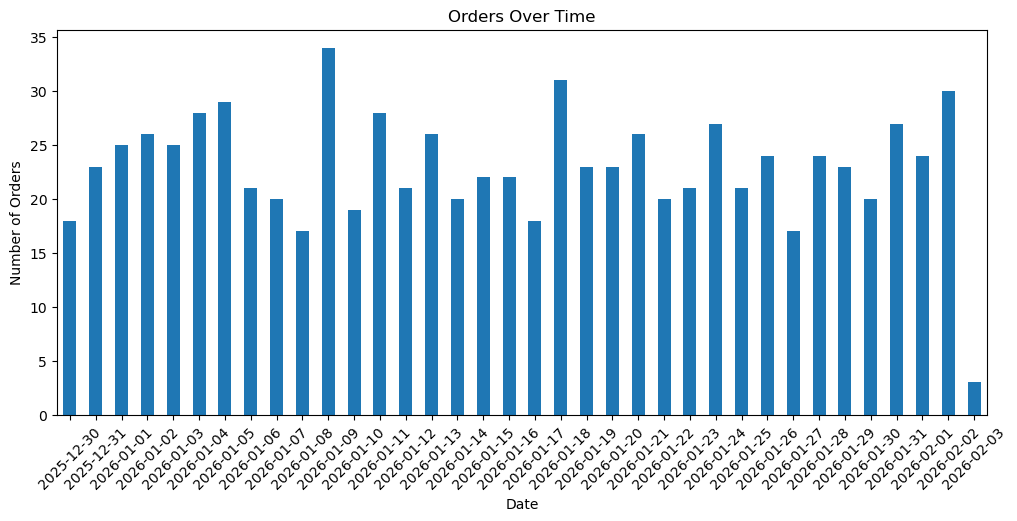

In [21]:
# finding potential trends by amount of orders over time
data["event_date"] = pd.to_datetime(data["event_date"])
purchases = data[data["event_type"] == "purchase"]
orders_over_time = purchases.groupby(

    purchases["event_date"].dt.date

).size()

orders_over_time.plot(kind="bar", figsize=(12,5))

plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.title("Orders Over Time")
plt.xticks(rotation=45)
plt.show()

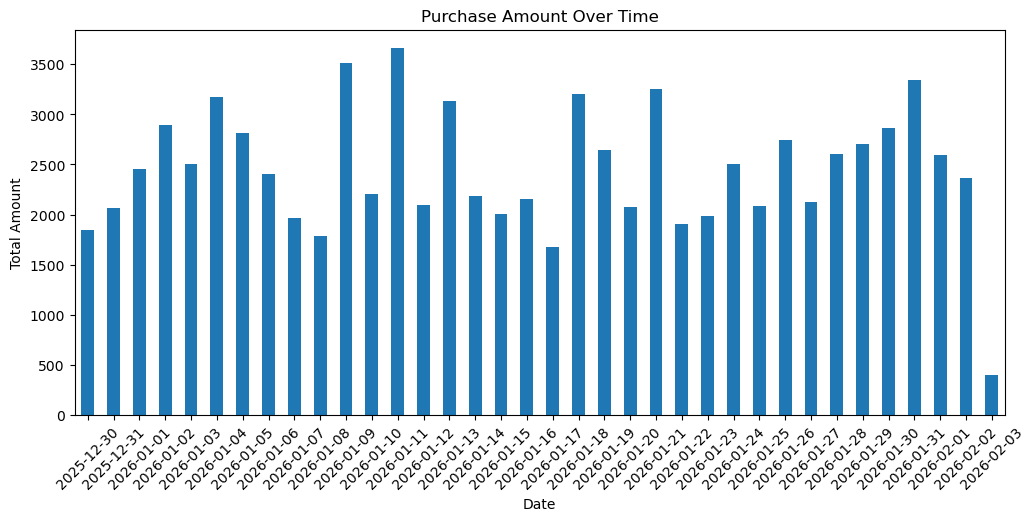

In [22]:
# finding potential trends by how much is spent over time
data["event_date"] = pd.to_datetime(data["event_date"])

purchases = data[data["event_type"] == "purchase"]

amount_over_time = purchases.groupby(
    purchases["event_date"].dt.date
)["amount"].sum()

amount_over_time.plot(kind="bar", figsize=(12,5))

plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.title("Purchase Amount Over Time")
plt.xticks(rotation=45)
plt.show()

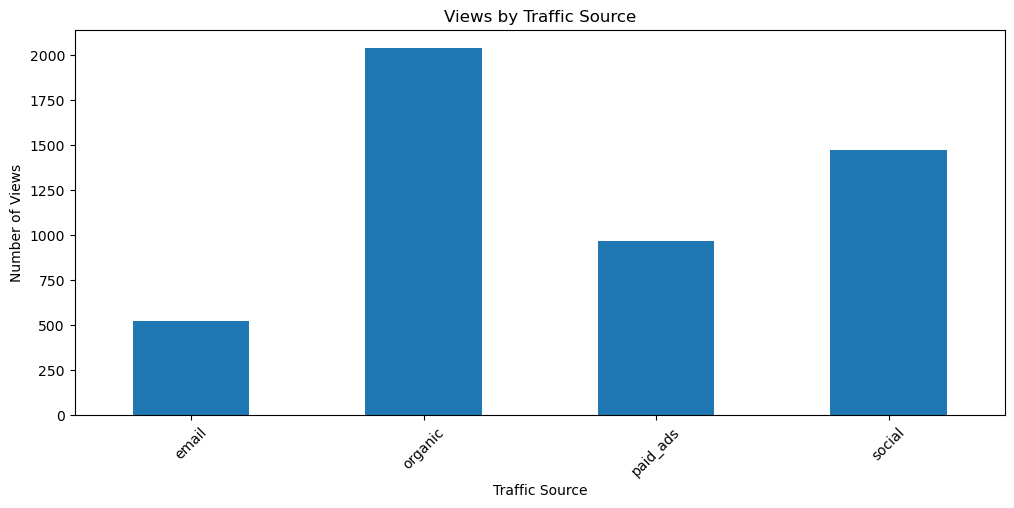

In [24]:
# examining traffic performance
views = data[data["event_type"] == "page_view"]

views_by_source = views.groupby(

    views["traffic_source"]

).size()

views_by_source.plot(kind="bar", figsize=(12,5))

plt.xlabel("Traffic Source")
plt.ylabel("Number of Views")
plt.title("Views by Traffic Source")
plt.xticks(rotation=45)
plt.show()

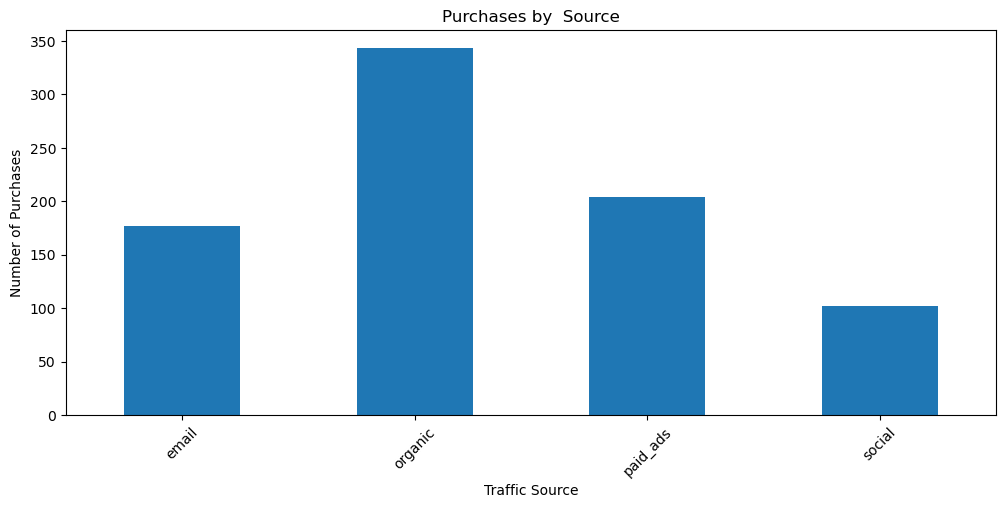

In [27]:
# diving deeper into the success of traffic performance
purchases = data[data["event_type"] == "purchase"]

purchases_by_source = purchases.groupby(

    purchases["traffic_source"]

).size()

purchases_by_source.plot(kind="bar", figsize=(12,5))

plt.xlabel("Traffic Source")
plt.ylabel("Number of Purchases")
plt.title("Purchases by  Source")
plt.xticks(rotation=45)
plt.show()

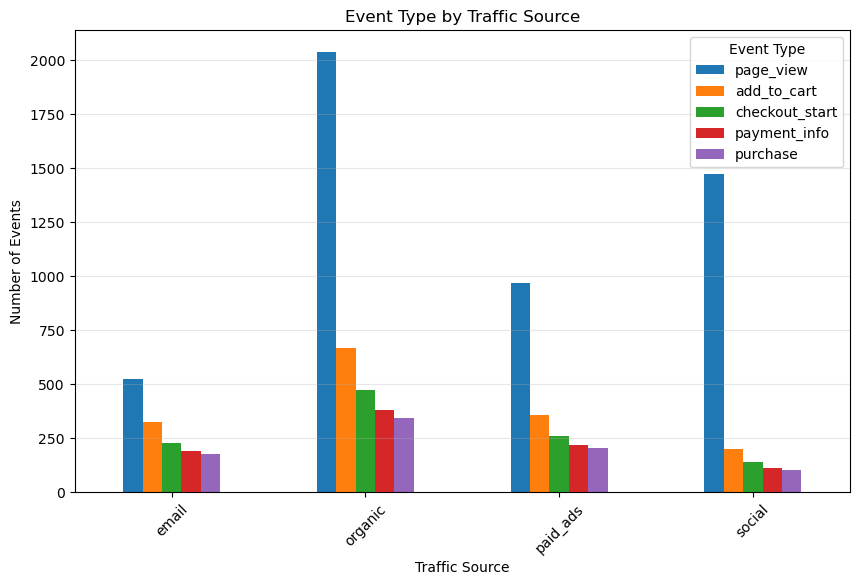

In [49]:
# graphing the cross analysis for better viewing
funnel = pd.crosstab(data["traffic_source"], data["event_type"])

funnel = funnel[
    ["page_view", "add_to_cart", "checkout_start", "payment_info", "purchase"]
]
funnel.plot(kind="bar", figsize=(10,6))

plt.xlabel("Traffic Source")
plt.ylabel("Number of Events")
plt.title("Event Type by Traffic Source")
plt.xticks(rotation=45)
plt.legend(title="Event Type")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [31]:
# cross analysis by tabling each stage
data["event_type"] = pd.Categorical(
    data["event_type"],
    categories=["page_view", "add_to_cart","checkout_start", "payment_info","purchase"],
    ordered=True
)

data.pivot_table(
    index="traffic_source",
    columns="event_type",
    aggfunc="size",
    fill_value=0
)

C:\Users\Samual\AppData\Local\Temp\ipykernel_9608\16117800.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table(


event_type,page_view,add_to_cart,checkout_start,payment_info,purchase
traffic_source,,,,,
email,522,326,228,190,177
organic,2038,669,473,381,343
paid_ads,968,358,261,216,204
social,1472,200,141,112,102


In [33]:
# conversion performance for each step
views = float((data["event_type"] == "page_view").sum())
carts = float((data["event_type"] == "add_to_cart").sum())
starts = float((data["event_type"] == "checkout_start").sum())
infos = float((data["event_type"] == "payment_info").sum())
purchases = float((data["event_type"] == "purchase").sum())

viewcart_ratio = carts/views
cartstart_ratio = starts/carts
startinfo_ratio = infos/starts
infopurchase_ratio = purchases/infos

print(f"Items to Cart: {viewcart_ratio} \nCart to Checkout: {cartstart_ratio} \nFilled Details: {startinfo_ratio} \nCheckout Completed: {infopurchase_ratio}")

Items to Cart: 0.3106 
Cart to Checkout: 0.7102382485511912 
Filled Details: 0.815049864007253 
Checkout Completed: 0.9187986651835373


In [35]:
# individual conversion performance to understand consumer behaviour
email_views = float((
    (data["event_type"] == "page_view") &
    (data["traffic_source"] == "email")
).sum())
email_purchases = float((
    (data["event_type"] == "purchase") &
    (data["traffic_source"] == "email")
).sum())

organic_views = float((
    (data["event_type"] == "page_view") &
    (data["traffic_source"] == "organic")
).sum())
organic_purchases = float((
    (data["event_type"] == "purchase") &
    (data["traffic_source"] == "organic")
).sum())

ads_views = float((
    (data["event_type"] == "page_view") &
    (data["traffic_source"] == "paid_ads")
).sum())
ads_purchases = float((
    (data["event_type"] == "purchase") &
    (data["traffic_source"] == "paid_ads")
).sum())

media_views = float((
    (data["event_type"] == "page_view") &
    (data["traffic_source"] == "social")
).sum())
media_purchases = float((
    (data["event_type"] == "purchase") &
    (data["traffic_source"] == "social")
).sum())

email_turnover = email_purchases/email_views
organic_turnover = organic_purchases/organic_views
ads_turnover = ads_purchases/ads_views
media_turnover = media_purchases/media_views

print(f"View to Purchase Ratios: \nEmail: {email_turnover} \nOrganic: {organic_turnover} \nPaid Ads: {ads_turnover} \nSocial Media: {media_turnover}")

View to Purchase Ratios: 
Email: 0.3390804597701149 
Organic: 0.16830225711481844 
Paid Ads: 0.21074380165289255 
Social Media: 0.06929347826086957


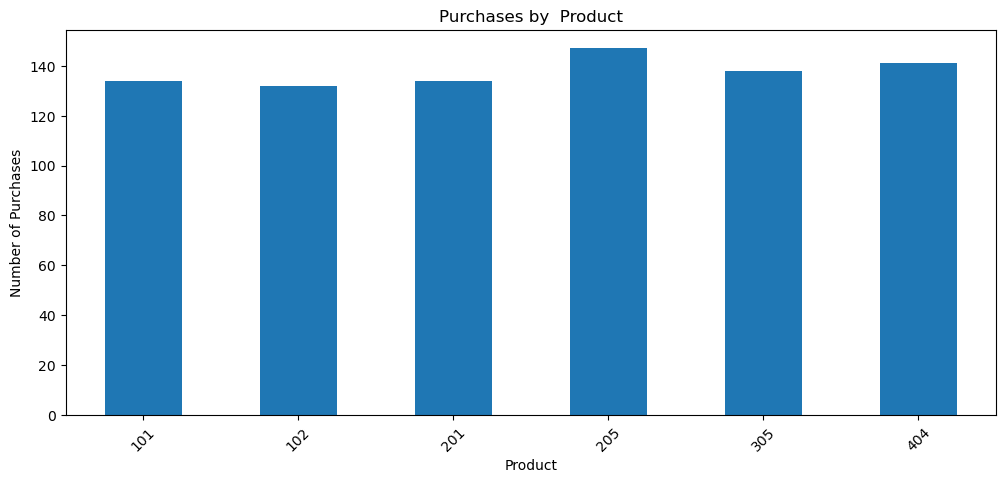

In [37]:
# product analysis
purchases = data[data["event_type"] == "purchase"]

purchases_by_product = purchases.groupby(

    purchases["product_id"]

).size()

purchases_by_product.plot(kind="bar", figsize=(12,5))

plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.title("Purchases by  Product")
plt.xticks(rotation=45)
plt.show()

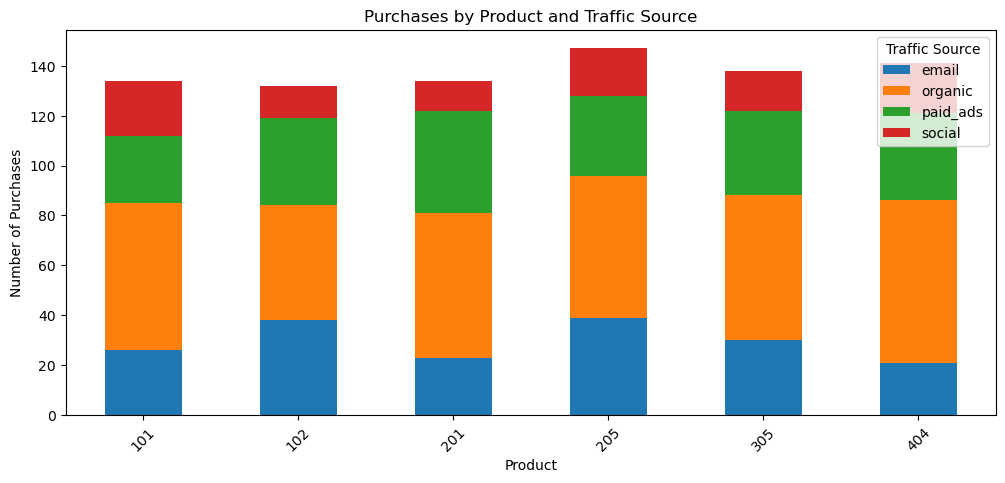

In [39]:
# further details from product analysis
purchases = data[data["event_type"] == "purchase"]

purchases_by_product = purchases.groupby(

    ["product_id", "traffic_source"]

).size().unstack(fill_value=0)

purchases_by_product.plot(kind="bar", stacked=True, figsize=(12, 5))

plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Product and Traffic Source")
plt.xticks(rotation=45)
plt.legend(title="Traffic Source")
plt.show()

In [47]:
# proportion of traffic spent per product
purchases = data[data["event_type"] == "purchase"]

product_source = pd.crosstab(
    purchases["traffic_source"],
    purchases["product_id"],
    normalize="index"
) * 100
product_source

product_id,101,102,201,205,305,404
traffic_source,,,,,,
email,14.689266,21.468927,12.994350,22.033898,16.949153,11.864407
organic,17.201166,13.411079,16.909621,16.618076,16.909621,18.950437
paid_ads,13.235294,17.156863,20.098039,15.686275,16.666667,17.156863
social,21.568627,12.745098,11.764706,18.627451,15.686275,19.607843
